https://www.statsmodels.org/stable/statespace.html#output-and-postestimation-methods-and-attributes

In [24]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import gruanpy as gp
from applications.pblh_unc.methodology import *
from applications.pblh_unc.plot_profile import *
import re
import pytz

In [ ]:
COEF=1

In [25]:
base = os.path.abspath(os.path.join(os.getcwd(), ".."))
pkl_path = os.path.join(base, "pblh_unc", "pkls", "gdp_2024_HKO-RS-01_2024.pkl")

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)

print("Dataset Loaded")


Dataset Loaded


In [26]:
def gdp_iterator(dataset):
    for pid, gdp in dataset.items():
        yield pid, gdp
iterator = gdp_iterator(dataset)

In [27]:
pid, gdp = next(iterator)
print(pid)

857565


In [28]:
upper_bound = gp._find_upper_bound(gdp.data[['alt']], upper_bound=3500, return_value=True)
gdp.data = gdp.data[gdp.data['alt'] <= upper_bound]
data=gdp.data

where = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Site.Name']['Value'].values[0]
when = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Measurement.StartTime']['Value'].values[0]
when = when[0:10] + " " + when[11:19]

# Standard plug-in PBLH
std_pblh = gp.pblh_values(gp.apply_pblh_methods(gdp.data))

In [ ]:
cols=['alt', 'temp', 'rh', 'press', 'wvmr_mass', 'wzon', 'wmeri']
for col in cols:
    data[col+'_uc']=data[col+'_uc']*COEF

In [30]:
model, results = fit_ssm(gdp, method="powell", iterations=100)

Optimization terminated successfully.
         Current function value: 0.614189
         Iterations: 4
         Function evaluations: 582


In [31]:
results_dict = {}

# 2. Smooth variables
smooth_vars = smooth_variables(results.smoothed_state, results.smoothed_state_cov)

# 3. SSM PBLH
sm_pblh = smooth_pblh(smooth_vars)

# 4. Monte‑Carlo simulations
M = 200
simulations = simulate_ssm(model, M, seed=42)

sim_pblh_list = []

for sim in simulations:
    sim_vars = smooth_variables(sim)  # uses smoothed_state only
    sim_pblh = smooth_pblh(sim_vars)
    sim_pblh_list.append(sim_pblh)

# Convert to DataFrame (this was missing!)
df_sim = pd.DataFrame(sim_pblh_list)

# Compute uncertainty statistics
pblh_unc = {
    key: {
        "mean": df_sim[key].mean(),
        "median": df_sim[key].median(),
        "std": df_sim[key].std(),
        "2.5": df_sim[key].quantile(0.025),
        "97.5": df_sim[key].quantile(0.975),
    }
    for key in ["pm", "thv", "rh", "ri"]
}

results_dict[pid] = {
    "std_pblh": std_pblh,
    "sm_pblh": sm_pblh,
    "smooth_vars": smooth_vars,
    "sim_pblh": df_sim,
    "pblh_unc": pblh_unc,
}

#print(results_dict)

# -----------------------------
# Extract smoothed variables + uncertainties
# -----------------------------
alt_s        = smooth_vars["alt"]
alt_s_unc    = smooth_vars["alt_unc"]

thv_s        = smooth_vars["thv"]
thv_s_unc    = smooth_vars["thv_unc"]

rh_s         = smooth_vars["rh"]
rh_s_unc     = smooth_vars["rh_unc"]

u_s          = smooth_vars["u"]
u_s_unc      = smooth_vars["u_unc"]

v_s          = smooth_vars["v"]
v_s_unc      = smooth_vars["v_unc"]

# Rates of change (vertical derivatives)
alt_rc_s     = smooth_vars["alt_rc"]
alt_rc_s_unc = smooth_vars["alt_rc_unc"]

thv_rc_s     = smooth_vars["thv_rc"]
thv_rc_s_unc = smooth_vars["thv_rc_unc"]

rh_rc_s      = smooth_vars["rh_rc"]
rh_rc_s_unc  = smooth_vars["rh_rc_unc"]

u_rc_s       = smooth_vars["u_rc"]
u_rc_s_unc   = smooth_vars["u_rc_unc"]

v_rc_s       = smooth_vars["v_rc"]
v_rc_s_unc   = smooth_vars["v_rc_unc"]

# Gradients
thv_g_s      = smooth_vars["thv_grad"]
thv_g_s_unc  = smooth_vars["thv_grad_unc"]

rh_g_s       = smooth_vars["rh_grad"]
rh_g_s_unc   = smooth_vars["rh_grad_unc"]

# Richardson number
ri_s         = smooth_vars["rich"]
ri_s_unc     = smooth_vars["rich_unc"]


# -----------------------------
# Extract observed variables + uncertainties (ONLY *_uc)
# -----------------------------

alt_o = data["alt"].values.astype(float)
alt_o_unc = data["alt_uc"].values.astype(float)

temp_o = data["temp"].values.astype(float)
temp_o_unc = data["temp_uc"].values.astype(float)

press_o = data["press"].values.astype(float)
press_o_unc = data["press_uc"].values.astype(float)

wvmr_o = data["wvmr_mass"].values.astype(float) * 1e-6
wvmr_o_unc = data["wvmr_mass_uc"].values.astype(float) * 1e-6

rh_o  = data["rh"].values.astype(float)
rh_o_unc = data["rh_uc"].values.astype(float)

u_o   = data["wzon"].values.astype(float)
u_o_unc = data["wzon_uc"].values.astype(float)

v_o   = data["wmeri"].values.astype(float)
v_o_unc = data["wmeri_uc"].values.astype(float)

# Virtual potential temperature + uncertainty
thv_o = gp.virtual_potential_temperature(temp_o, press_o, wvmr_o)
thv_o_unc = gp.virtual_potential_temperature_uncertainty(
    temp_o, press_o, wvmr_o,
    temp_o_unc, press_o_unc, wvmr_o_unc
)

# Observed gradients + uncertainties
thv_g_o = gp.finite_difference_gradient(pd.Series(thv_o), pd.Series(alt_o))
thv_g_o_unc = gp.finite_difference_gradient_uncertainty(
pd.Series(thv_o),
pd.Series(alt_o),
pd.Series(thv_o_unc),
pd.Series(alt_o_unc))

rh_g_o  = gp.finite_difference_gradient(pd.Series(rh_o), pd.Series(alt_o))
rh_g_o_unc = gp.finite_difference_gradient_uncertainty(
pd.Series(rh_o),
pd.Series(alt_o),
pd.Series(rh_o_unc),
pd.Series(alt_o_unc)
)

# Observed Richardson number + uncertainty

ri_o = gp.bulk_richardson_number(thv_o[0], thv_o, alt_o, u_o, v_o)

ri_o_unc = gp.bulk_richardson_number_uncertainty_np(
thv_o[0], thv_o, alt_o, u_o, v_o,
thv_o_unc[0], thv_o_unc, alt_o_unc, u_o_unc, v_o_unc
)

pblh_info = {
"pm": {
    "value":  std_pblh[0],
    "median": pblh_unc["pm"]["median"],
    "low":    pblh_unc["pm"]["2.5"],
    "high":   pblh_unc["pm"]["97.5"],
},

"thv": {
    "value":  std_pblh[1],
    "median": pblh_unc["thv"]["median"],
    "low":    pblh_unc["thv"]["2.5"],
    "high":   pblh_unc["thv"]["97.5"],
},

"rh": {
    "value":  std_pblh[2],
    "median": pblh_unc["rh"]["median"],
    "low":    pblh_unc["rh"]["2.5"],
    "high":   pblh_unc["rh"]["97.5"],
},

"ri": {
    "value":  std_pblh[3],
    "median": pblh_unc["ri"]["median"],
    "low":    pblh_unc["ri"]["2.5"],
    "high":   pblh_unc["ri"]["97.5"],
}}

# Add MC samples to pblh_info
pblh_info["pm"]["samples"]  = df_sim["pm"].values
pblh_info["thv"]["samples"] = df_sim["thv"].values
pblh_info["rh"]["samples"]  = df_sim["rh"].values
pblh_info["ri"]["samples"]  = df_sim["ri"].values

where = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Site.Name']['Value'].values[0] # location
when = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Measurement.StartTime']['Value'].values[0] # time
when=when[0:10]
tod=gdp.global_attrs[gdp.global_attrs['Attribute'] == "g.Measurement.TimeOfDay"]['Value'].values[0] # time


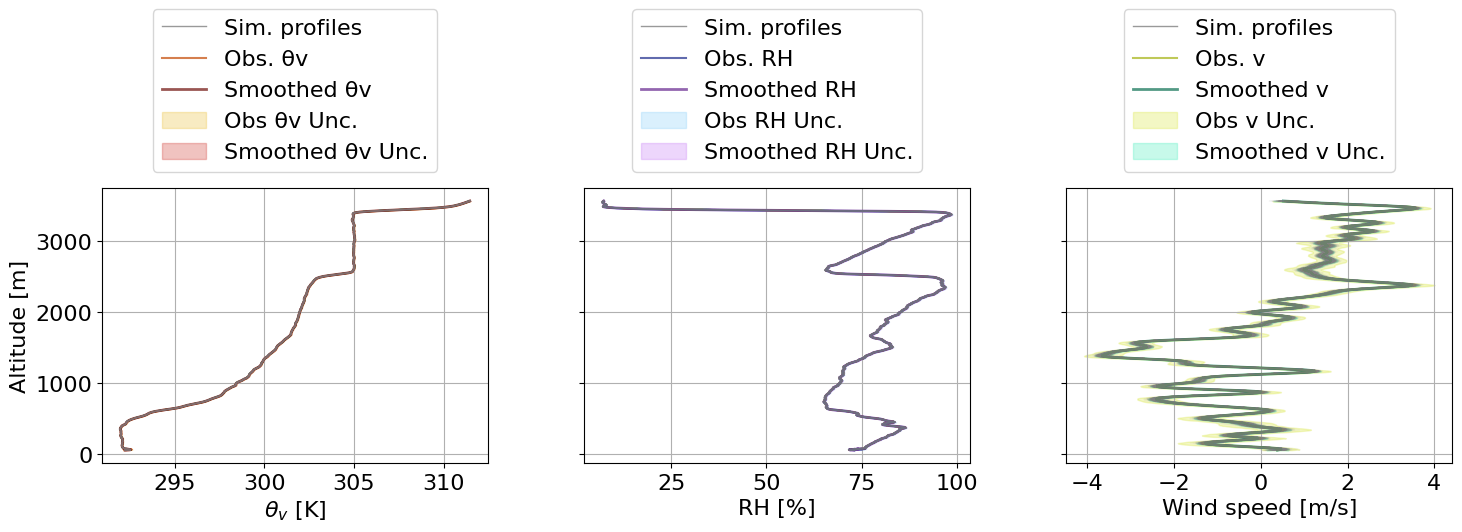

In [32]:
plot_ssm_diagnostics_short(
            pid, where, when, tod,
            alt_o, thv_o, rh_o, u_o, v_o,
            thv_o_unc, rh_o_unc, u_o_unc, v_o_unc,
            alt_s, thv_s, rh_s, u_s, v_s,
            thv_s_unc, rh_s_unc, u_s_unc, v_s_unc,
            simulations,
            None,#pblh_info,
            map_labels_to_colors,
            scatter_obs=False)

In [33]:
# - Print a table summarizing estimation results
print(results.summary())


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:                           LocalLinearTrend   Log Likelihood                -394.923
Date:                            Wed, 29 Jul 2026   AIC                            809.846
Time:                                    10:47:28   BIC                            854.351
Sample:                                         0   HQIC                           827.130
                                            - 643                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alt_sigma2.level  1.662e-16      0.794   2.09e-16      1.000      -1.557       1.557
alt_sigma2.trend 

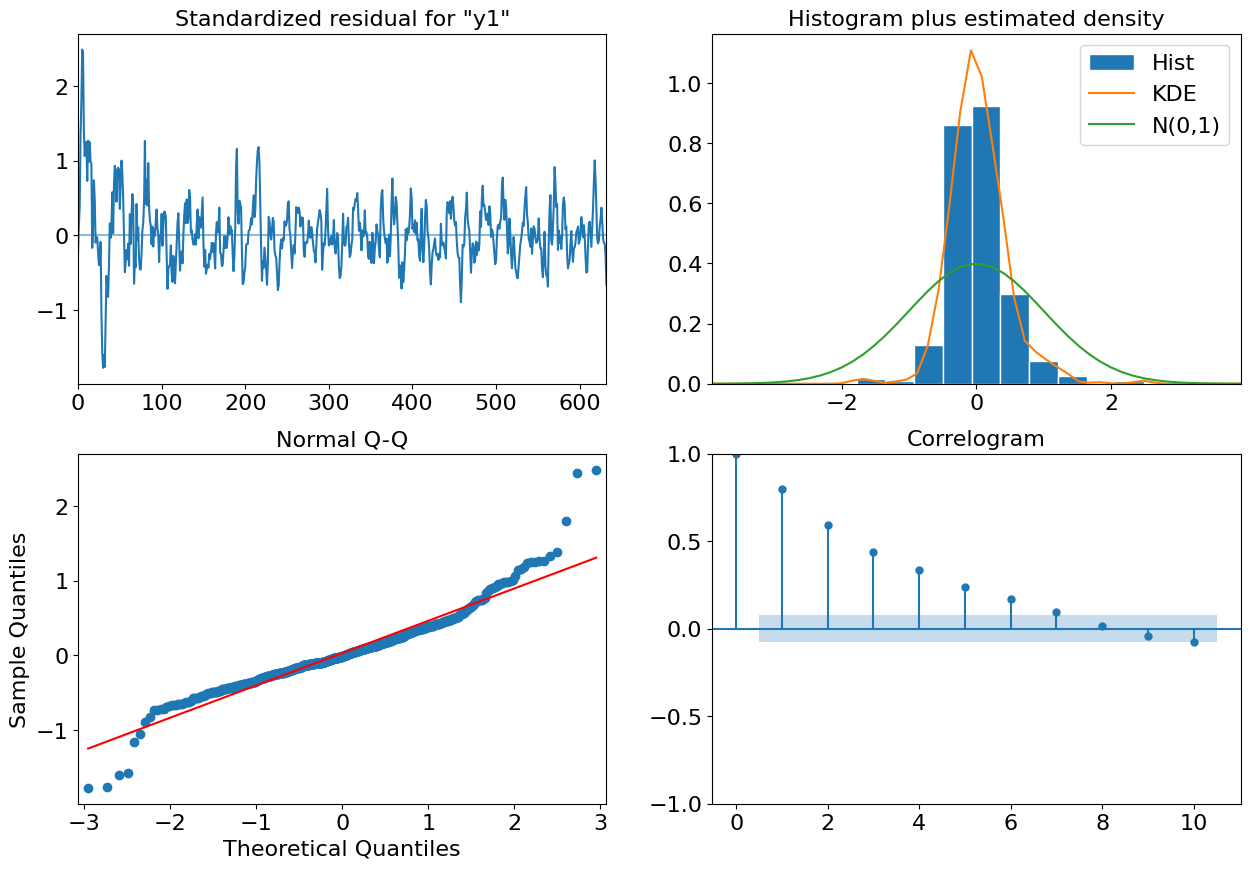

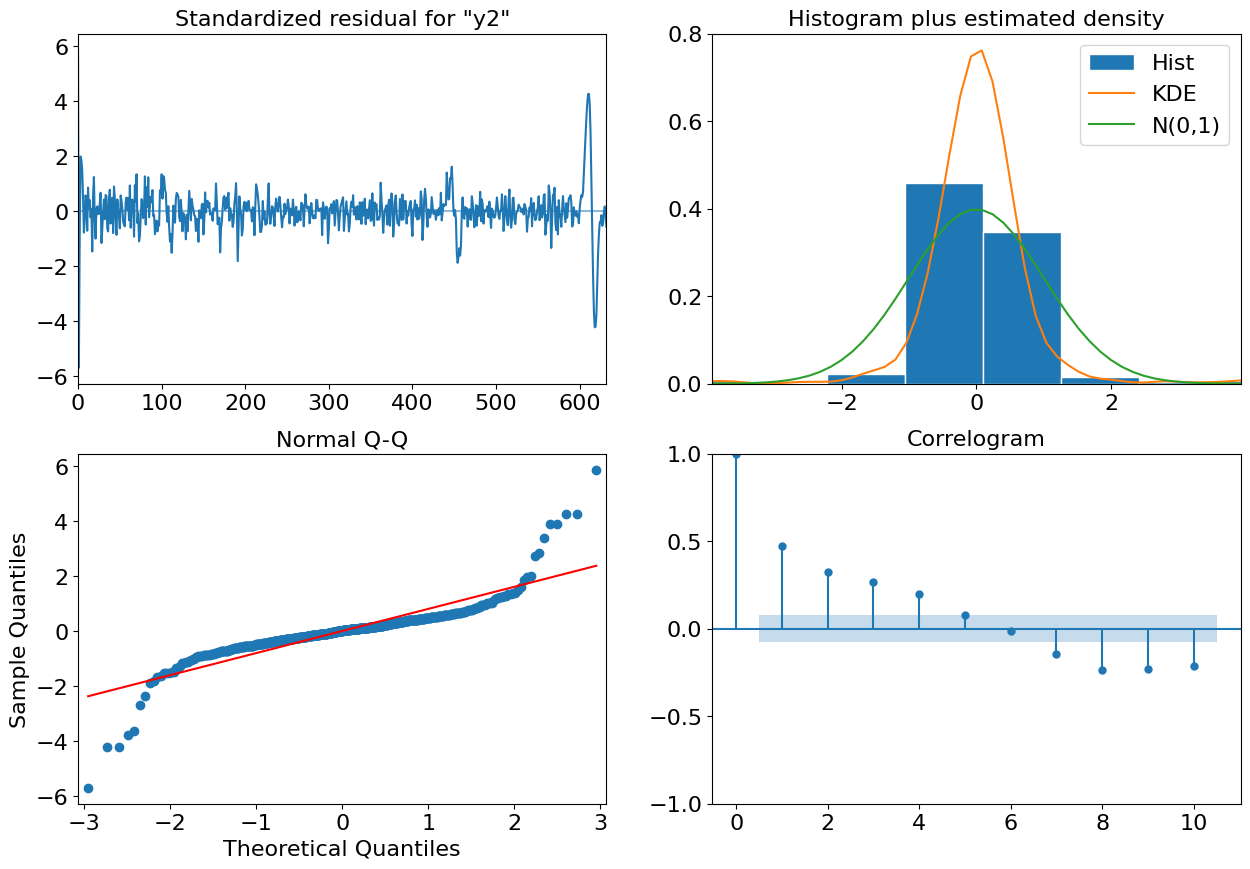

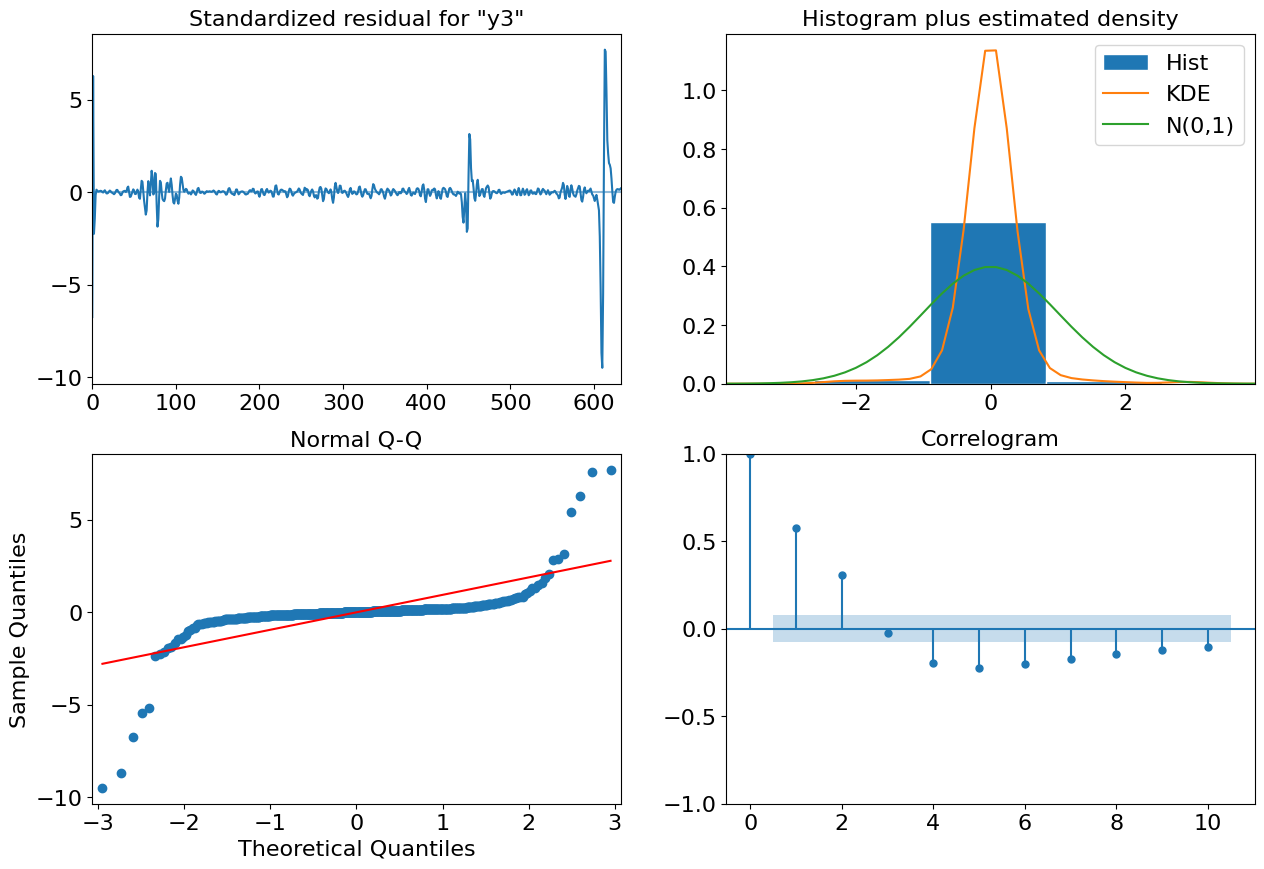

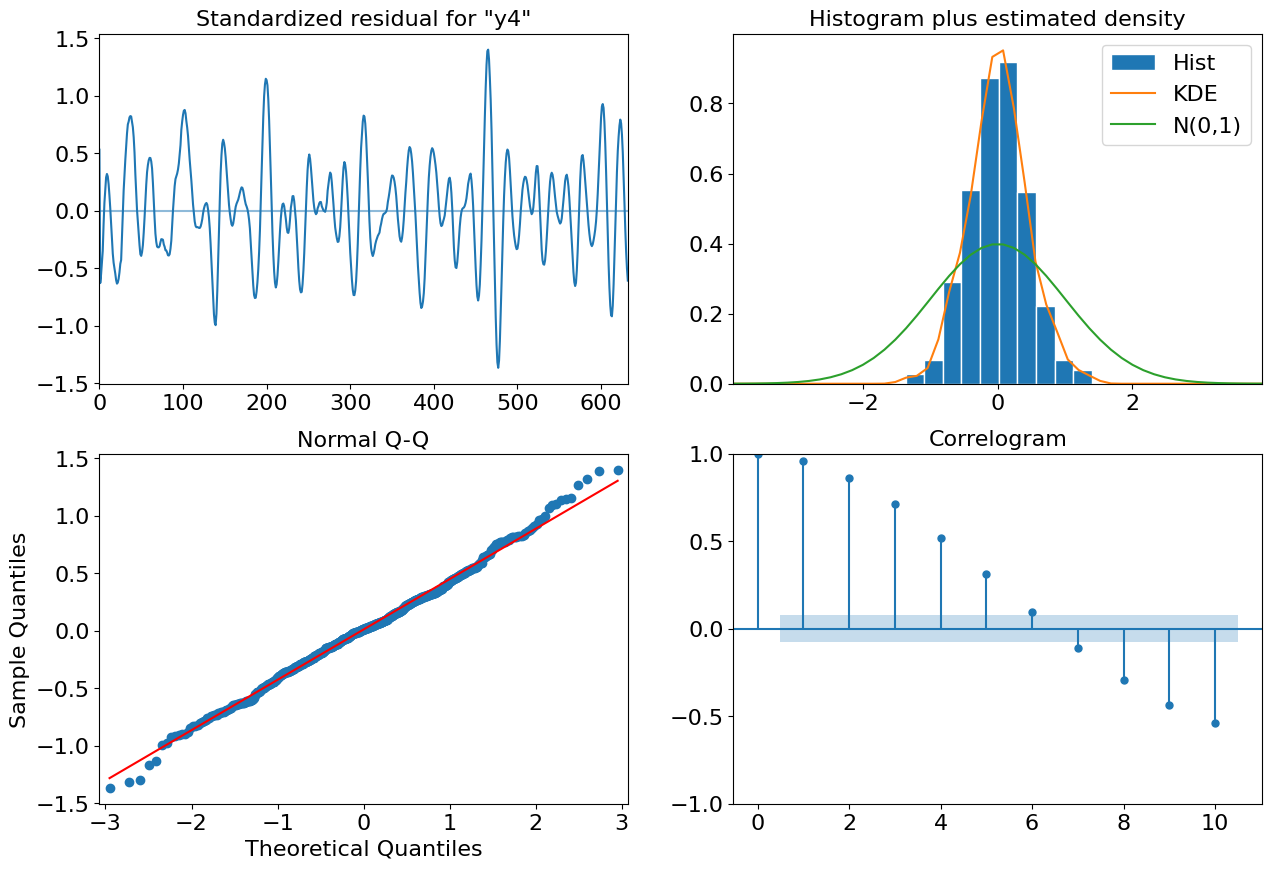

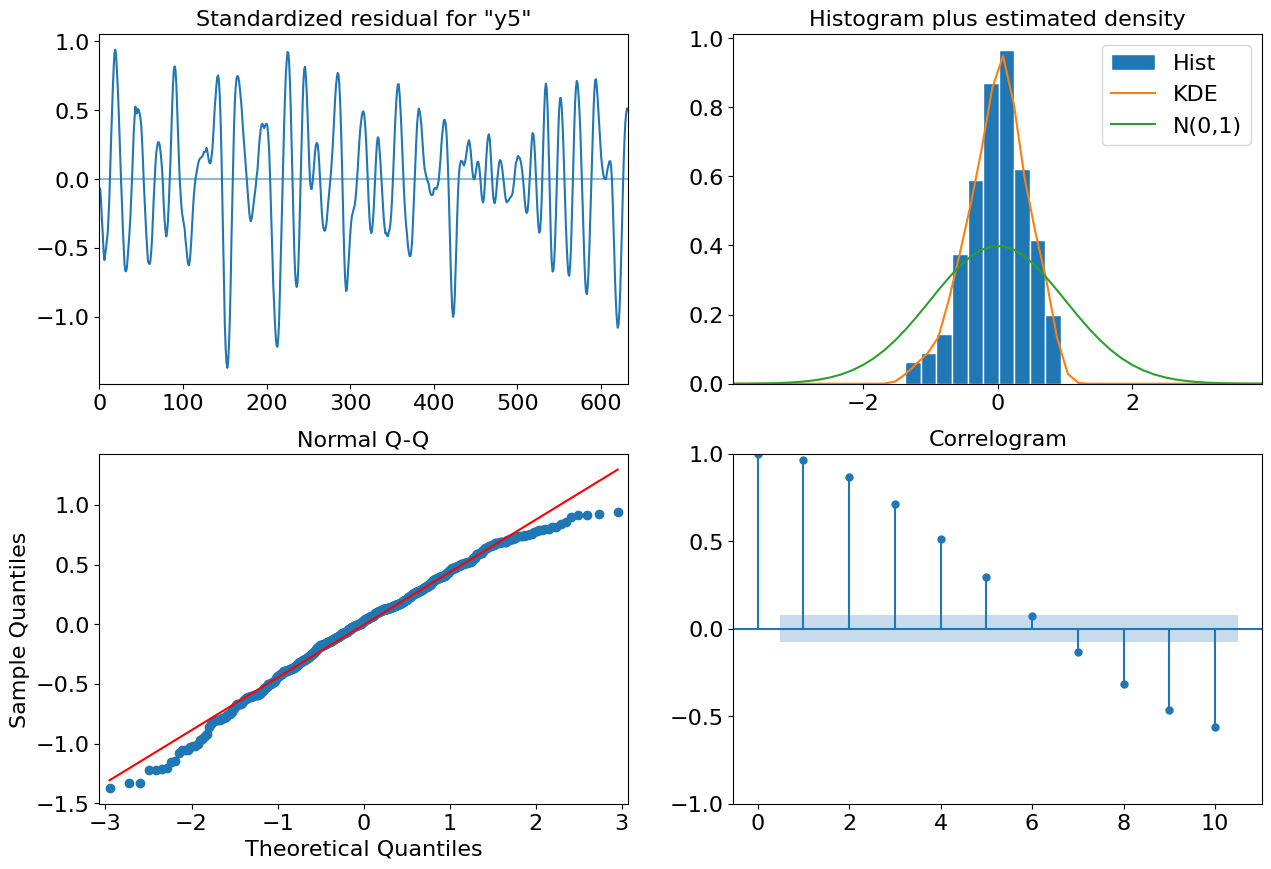

In [34]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    plt.show(block=True)